Let's implement the following models, all driven by 1-3 independent/correlated brownian motions. In the future, one of them will become fractional. 

(1) "The dynamics of stochastic volatility: evidence from underlying and options markets" - Jones, p.186: $W^1, W^2$ independent,

$$ \mathrm{d}S_t = \mu S_t \mathrm{d}t + \sqrt{V_t} S_t \mathrm{d}W^1_t, \qquad \mathrm{d}V_t = (\alpha + \beta V_t)\mathrm{d}t + \sigma_1 V_t^{\gamma_1} \mathrm{d}W^1_t + \sigma_2 V_t^{\gamma_2} \mathrm{d}W^2_t $$

(I guess without the drift in the equation for $S_t$)

(2) "The quadratic rough Heston model and the joint S&P 500/VIX smile calibration problem" - Gatheral, Jusselin, Rosenbaum, p.3-4 (non-Volterra version): $W^1$ and $W^2$ possibly correlated,

$$ \mathrm{d}S_t = S_t\sqrt{a(Z_t - b)^2 + c\,} \mathrm{d}W^1_t \qquad \mathrm{d}Z_t = \lambda (\theta(s) - Z_t)\mathrm{d}t + \lambda \eta \sqrt{a(Z_t - b)^2 + c\,} \mathrm{d} W^2_t $$

We will try to solve all equations in the way that is most similar to how they will be solved in the fractional case.


For later:

(3) "Fast Ninomiya-Victoir calibration of the Double-Mean-Reverting Model" - Bayer, Gatheral, Karlsmark, p.2: $W^1, W^2, W^3$ correlated $\mathrm{d}W^i_t \mathrm{d}W^j_t = \rho^{ij}\mathrm{d} t$,

$$ \mathrm{d} S_t = \sqrt{V_t} S_t \mathrm{d}W^1, \qquad \mathrm{d} v_t = \kappa_1 (V_t' - V_t)\mathrm{d}t + \xi_1 V_t^{\alpha_1} \mathrm{d}W^2_t, \qquad \mathrm{d} V'_t = \kappa_2 (\vartheta - V_t') \mathrm{d}t + \xi_2 V_t^{\alpha_2}\mathrm{d}W^3_t $$

(4) "Rough multifactor volatility for SPX and VIX options" - Jacquier, Muguruza, Pannier, p.4

$$ \mathrm{d} S_t = \sqrt{V_t} S_t \mathrm{d}W^1? \qquad V_t = V_0 \Big[\chi \exp \Big( \nu W^1_t + \frac{\nu^2}{2} t^{2H} \Big) + (1-\chi) \exp \Big( \eta W^1_t + \frac{\eta^2}{2} t^{2H} \Big) \Big] $$

What's the equation for $V$? It can be tested against the expression above.

In [1]:
# Imports
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from diffrax import *
from controls import *

In [2]:
# Global default parameters
t0, t1 = 0, 1
epsilon = 0.0001
lag = 1.2*epsilon
solver_epsilon = 0.01*epsilon
times = jnp.arange(t0, t1, epsilon)
num_samples = 5
dim_bm = 2

In [3]:
# (1) Dynamics of stoch vol. We want to solve this one without any correlation/lead-lag. Therefore we just use an Ito solver.

gamma1 = 1.2
gamma2 = 1.2
sigma1 = 1.5
sigma2 = 1.5
alpha = 1.5
beta = 1.5


y0 = jnp.array([1, 1])
drift_jones = lambda t, y, args: jnp.array([0, alpha + beta*y[1]])
diffusion_jones = lambda t, y, args: jnp.array([[jnp.sqrt(y[1])*y[0], 0], [sigma1*jnp.power(y[1], gamma1), sigma2*jnp.power(y[1], gamma2)]])
saveat = SaveAt(ts = times)

In [4]:
key=jr.PRNGKey(510)
split_key = jax.random.split(key, num_samples)

solutions = vmap_batch_solve(split_key, epsilon, dim_bm, drift_jones, diffusion_jones, y0, Euler(), t0, t1, solver_epsilon, saveat)

In [76]:
# Let's check that using Euler instead of Midpoint as a solver does not change the solution (because time step of solver is finer than resolution of the data)
solutions_euler = vmap_batch_solve(split_key, epsilon, dim_bm, drift_jones, diffusion_jones, y0, Euler(), t0, t1, solver_epsilon, saveat)

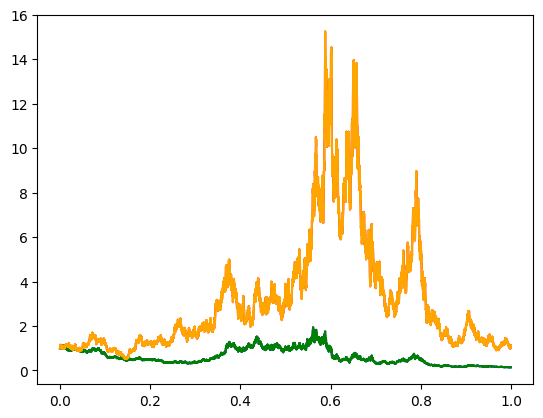

In [82]:
a, b = 0, 10000
path = 3
plt.plot(solutions.ts[path, a : b], solutions.ys[path, a : b, 0], color = "blue")
plt.plot(solutions.ts[path, a : b], solutions.ys[path, a : b, 1], color = "red")
plt.plot(solutions_euler.ts[path, a : b], solutions_euler.ys[path, a : b, 0], color = "green")
plt.plot(solutions_euler.ts[path, a : b], solutions_euler.ys[path, a : b, 1], color = "orange")

# The solutions are almost indistinguishable

This is actually the wrong solution, because it is Stratonovich. Let's write the original equation in Stratonovich form, solve it with our finer solver, and check that it agrees with the Ito solution.

$$ \mathrm{d}S_t = \sqrt{V_t} S_t \circ \mathrm{d}W^1_t - \frac 12  \bigg( V_t S_t \mathrm{d}[W^1]_t + \frac 12 \sigma_1 V_t^{\gamma_1-1/2} S_t \mathrm{d}[W^1]_t + \frac 12 \sigma_2 V_t^{\gamma_2-1/2} S_t \mathrm{d}[W^1, W^2]_t \bigg)$$

$$\mathrm{d}V_t = (\alpha + \beta V_t)\mathrm{d}t + \sigma_1 V_t^{\gamma_1} \circ \mathrm{d} W^1_t + \sigma_2 V_t^{\gamma_2} \circ \mathrm{d}W^2_t - \frac 12 \bigg( \sigma_1^2 \gamma_1 V_t^{2\gamma_1 - 1} \mathrm{d}[W^1]_t + \sigma_2^2 \gamma_2 V_t^{2\gamma_2 - 1} \mathrm{d}[W^2]_t + \sigma_1 \sigma_2 (\gamma_1 + \gamma_2) V_t^{\gamma_1 + \gamma_2 - 1} \mathrm{d}[W^1,W^2]_t \bigg)$$

We're taking $[W^1]_t = t = [W^2]_t$ and $[W^1,W^2] = 0$, so we have

$$ \mathrm{d}S_t = \sqrt{V_t} S_t \circ \mathrm{d}W^1_t - \frac 12  \bigg( V_t S_t + \frac 12 \sigma_1 V_t^{\gamma_1-1/2} S_t \bigg) \mathrm{d} t $$

$$\mathrm{d}V_t =  \sigma_1 V_t^{\gamma_1} \circ \mathrm{d} W^1_t + \sigma_2 V_t^{\gamma_2} \circ \mathrm{d}W^2_t + (\alpha + \beta V_t)\mathrm{d}t - \frac 12 \bigg( \sigma_1^2 \gamma_1 V_t^{\gamma_1 - 1}  + \sigma_2^2 \gamma_2 V_t^{\gamma_2 - 1} \bigg) \mathrm{d} t $$

Note that when we will take $W^2$ to be a fBm, $[W^2] = \infty$ and $[W^1,W^2] = \infty$ also if they are correlated, so these infinite terms cannot appear individually (they are absorbed in the lead-lag). 

In [135]:
#let's first simulate the Ito solution: this requires step size of solver equal to (or coarser) than step size of data

solver_epsilon = epsilon
solutions_true = vmap_batch_solve(split_key, epsilon, dim_bm, drift_jones, diffusion_jones, y0, Euler(), t0, t1, solver_epsilon, saveat)

In [141]:
# now let's check that it matches the Stratonovich solution with corrected drift, with finer step size of solver again

solver_epsilon = 0.01*epsilon
drift_jones_strat = lambda t, y, args: jnp.array([-(1/2)*(y[1]*y[0]+ (1/2)*sigma1*jnp.power(y[1], gamma1-1/2)*y[0]), alpha + beta*y[1] -(1/2) * ( jnp.power(sigma1,2)*gamma1*jnp.power(y[1], 2*gamma1-1) + jnp.power(sigma2,2)*gamma2*jnp.power(y[1], 2*gamma2-1) ) ])
diffusion_jones_strat = lambda t, y, args: jnp.array([[jnp.sqrt(y[1])*y[0], 0], [sigma1*jnp.power(y[1], gamma1), sigma2*jnp.power(y[1], gamma2)]])
solutions_strat = vmap_batch_solve(split_key, epsilon, dim_bm, drift_jones_strat, diffusion_jones_strat, y0, Midpoint(), t0, t1, solver_epsilon, saveat)

In [142]:
# Solution simulated in Strat form (with drift that makes it Ito) but with coarse solver

solver_epsilon = epsilon
solutions_strat_coarse = vmap_batch_solve(split_key, epsilon, dim_bm, drift_jones_strat, diffusion_jones_strat, y0, Midpoint(), t0, t1, solver_epsilon, saveat)

# Note how faster the coarse solver is...

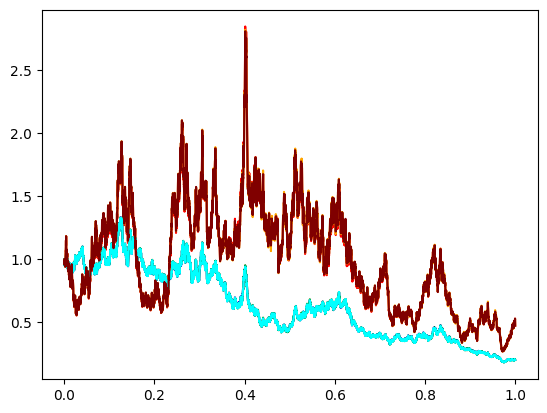

In [145]:
a, b = 0, 10000
path = 2
plt.plot(solutions_true.ts[path, a : b], solutions_true.ys[path, a : b, 0], color = "blue")
plt.plot(solutions_true.ts[path, a : b], solutions_true.ys[path, a : b, 1], color = "red")
plt.plot(solutions_strat.ts[path, a : b], solutions_strat.ys[path, a : b, 0], color = "green")
plt.plot(solutions_strat.ts[path, a : b], solutions_strat.ys[path, a : b, 1], color = "orange")
plt.plot(solutions_strat_coarse.ts[path, a : b], solutions_strat_coarse.ys[path, a : b, 0], color = "cyan")
plt.plot(solutions_strat_coarse.ts[path, a : b], solutions_strat_coarse.ys[path, a : b, 1], color = "maroon")

# They match.
# Important reminder: when doing the fractional case, we will have to check that coarsening the solver does not change the solution.

In [55]:
# Now let's solve them sequentially: first the volatility, then the price. This is how we will do it in the fractional case.

solver_epsilon = epsilon
y0 = jnp.array([1])
drift_jones_V = lambda t, y, args: jnp.array([alpha + beta*y[1] -(1/2) * ( jnp.power(sigma1,2)*gamma1*jnp.power(y[1], 2*gamma1-1) + jnp.power(sigma2,2)*gamma2*jnp.power(y[1], 2*gamma2-1) ) ])
diffusion_jones_V = lambda t, y, args: jnp.array([[sigma1*jnp.power(y[1], gamma1), sigma2*jnp.power(y[1], gamma2)]])
solutions_V = vmap_batch_solve(split_key, epsilon, dim_bm, drift_jones_V, diffusion_jones_V, y0, Midpoint(), t0, t1, solver_epsilon, saveat)
V = batch_sol_to_fun(solutions_V, num_samples)

y0 = jnp.array([1])
drift_jones_S = lambda t, y, args: jnp.array([0]) # Note we have put the Ito drift here

diffusion_jones_S = [lambda t, y, args: jnp.array(jnp.sqrt(V(t)[k])*y[0]) for k in range(num_samples)]

diffusion_jones_S[0](0.5,jnp.array([1]),0)


solution_S = jax.vmap(batch_solve, in_axes=(0, None, None, None, 0, None, None, None, None, None, None))(split_key, epsilon, dim_bm, drift_jones_S, diffusion_jones_S, y0, Euler(), t0, t1, solver_epsilon, saveat)

NameError: name 't' is not defined

In [ ]:
plt.plot(solutions_strat_coarse.ts[path, a : b], solutions_strat_coarse.ys[path, a : b, 0], color = "cyan")
plt.plot(solutions_strat_coarse.ts[path, a : b], solutions_strat_coarse.ys[path, a : b, 1], color = "maroon")
plt.plot(solutions_strat_coarse.ts[path, a : b], solutions_strat_coarse.ys[path, a : b, 0], color = "cyan")
plt.plot(solutions_strat_coarse.ts[path, a : b], solutions_strat_coarse.ys[path, a : b, 1], color = "maroon")

In [10]:
# (2) Quadratic rough Heston. We would like to solve this with correlation and lead-lag. We start with full correlation.

a = 1
b = 0.5
c = 1
theta = 1
lam = 1
eta = 1

dim_bm = 1
y0 = jnp.array([1, 1])
drift_qrh = lambda t, y, args: jnp.array([0, lam*(theta - y[1])])
diffusion_qrh = lambda t, y, args: jnp.array([[ y[0] * jnp.sqrt( a * jnp.square( y[1] - b )+ c ) ], [ lam * eta * jnp.sqrt( a * jnp.square( y[1] - b )+ c ) ]])
solutions = vmap_batch_solve(split_key, epsilon, dim_bm, drift_qrh, diffusion_qrh, y0, Midpoint(), t0, t1, solver_epsilon, saveat)

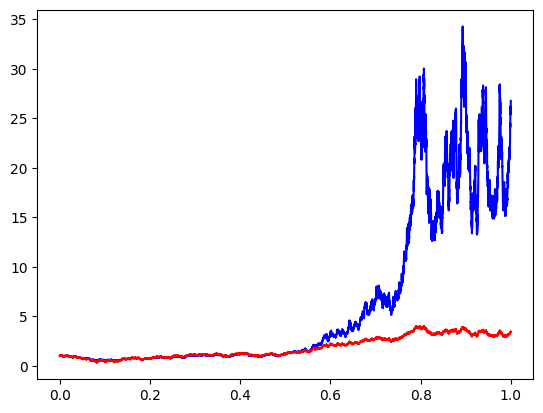

In [18]:
a, b = 0, 10000
path = 1
plt.plot(solutions.ts[path, a : b], solutions.ys[path, a : b, 0], color = "blue")
plt.plot(solutions.ts[path, a : b], solutions.ys[path, a : b, 1], color = "red")

Next: 

- There is a mistake: we are simulating Stratonovich, not Ito. Check this is true.
- Solving $V$ first in Strat form and then $S$ in Ito form separately (step size same as brownian).
- What about solving together with lead-lag, is this even possible? Understand exactly what the lead-lag scheme is doing in the classical case

- Write code for producing 2 or 3 brownian motions with arbitrary correlation structure
- Consider the above models in this case
